**PERÍODO ACADÉMICO:** 2026-A  
**ASIGNATURA:** ICCD412 Métodos Numéricos  
**GRUPO:** GR2  
**TIPO DE INSTRUMENTO:** AVANCE PROYECTO
**FECHA DE ENTREGA LÍMITE:** 21/06/2026  
**ALUMNO:** Jose Pallares, Jhosua Saa, Erick Toapanta.


### Etapa 1: Tratamiento de Datos

En esta primera etapa, preparamos el entorno de trabajo aislando la ventana temporal estricta de interés (octubre 2019 - octubre 2024) y limpiando el ruido a nivel de sistema para garantizar cálculos numéricos estables en las fases posteriores.

**Los desafíos identificados son:**
* **Filtrado Temporal:** Se aísla el periodo post-pandemia utilizando máscaras booleanas para trabajar únicamente con los 5 años exactos de interés.
* **Aritmética de Punto Flotante:** Se aplica un redondeo estricto a 8 decimales en el precio de cierre para mitigar el riesgo de acumulación de errores de truncamiento y propagación al resolver matrices.
* **Variable Independiente:** Los modelos matemáticos operan sobre ejes continuos en los números reales, no sobre objetos de calendario. Se crea la variable $t$, donde cada unidad de incremento representa un día hábil de operación bursátil.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

In [9]:

# --- 1. TRATAMIENTO DE DATOS ---
archivo = 'NASDAQ100.csv' # Nombre del archivo

try:
    df_total = pd.read_csv(archivo)

    # Convertir la columna Date a formato fecha
    df_total['Date'] = pd.to_datetime(df_total['Date'])

    # FILTRADO (Oct 2019 - Oct 2024)
    fecha_inicio = pd.to_datetime('2019-10-01')
    fecha_fin = pd.to_datetime('2024-10-31')
    mascara = (df_total['Date'] >= fecha_inicio) & (df_total['Date'] <= fecha_fin)

    # Nos quedamos solo con los datos que cumplen la condición
    df_analisis = df_total.loc[mascara].sort_values('Date').reset_index(drop=True).copy()

    # Estandarización a 8 decimales por redondeo
    df_analisis['Close'] = df_analisis['Close'].round(8)

    # Creación de variable independiente t (días de operación)
    df_analisis['t'] = np.arange(len(df_analisis))

    print("--- ETAPA 1: TRATAMIENTO COMPLETADO ---")
    print(f"Rango de datos: {df_analisis['Date'].min().date()} a {df_analisis['Date'].max().date()}")
    print(f"Total de registros (n): {len(df_analisis)}")
    print(f"Precio Mínimo: {df_analisis['Close'].min():.2f} | Precio Máximo: {df_analisis['Close'].max():.2f}")

except Exception as e:
    print(f"Error al procesar los datos: {e}")

--- ETAPA 1: TRATAMIENTO COMPLETADO ---
Rango de datos: 2019-10-01 a 2024-10-25
Total de registros (n): 1340
Precio Mínimo: 24.29 | Precio Máximo: 75.24


### Etapa 2: Interpolación y Suavizado

En esta fase, reconstruimos la trayectoria del índice NASDAQ-100 mitigando las fluctuaciones de alta frecuencia (el "ruido" diario) para obtener una función continua que sea matemáticamente tratable sin perder la fidelidad de los datos reales.

**Interpretación Técnica:**
* **Fidelidad de los Datos:** A diferencia de un ajuste global, la curva generada en esta etapa intercepta exactamente cada registro de precio de cierre diario de la base de datos.
* **Continuidad y Suavidad:** Se implementan Splines Cúbicos en lugar de una interpolación polinómica tradicional para evitar las oscilaciones catastróficas en los extremos (Fenómeno de Runge). Esto garantiza que en cada nodo de unión, la primera y segunda derivada sean idénticas.
* **Vector Denso de Evaluación:** Se genera un espacio muestral de 1000 puntos para trazar una curva fluida que facilita la identificación visual de la inercia del mercado.

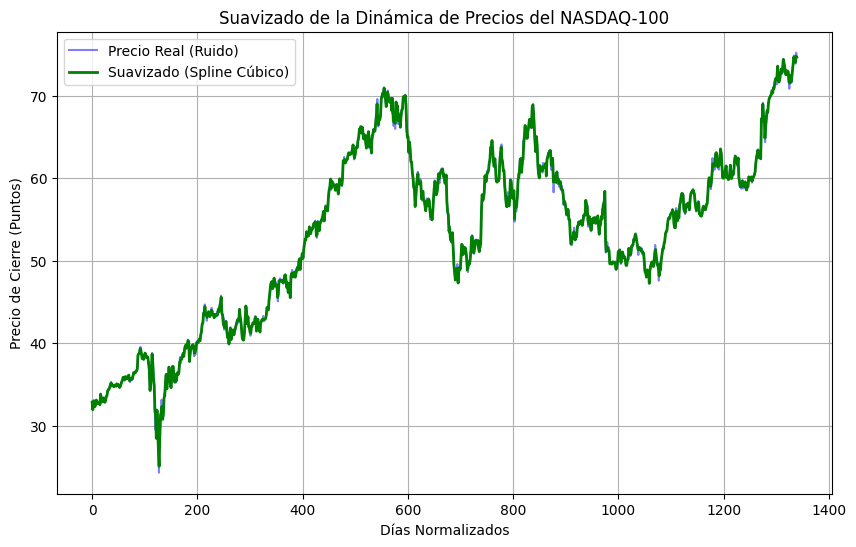

In [10]:
# 1. Preparación de vectores para la interpolación
t = df_analisis['t'].values
y = df_analisis['Close'].values

# 2. Cálculo de los coeficientes del spline cúbico natural
# Garantiza que la segunda derivada en los extremos sea cero
spline = CubicSpline(t, y, bc_type='natural')

# 3. Generación de un espacio muestral denso para visualización fluida
t_suave = np.linspace(t.min(), t.max(), 1000)
y_spline = spline(t_suave)

# 4. Configuración del entorno gráfico estandarizado
plt.figure(figsize=(10, 6))

# Trazado de datos crudos con opacidad reducida para no saturar
plt.plot(t, y, color='blue', alpha=0.5, label='Precio Real (Ruido)')

# Trazado de la curva interpolada
plt.plot(t_suave, y_spline, color='green', linewidth=2, label='Suavizado (Spline Cúbico)')

plt.title('Suavizado de la Dinámica de Precios del NASDAQ-100')
plt.xlabel('Días Normalizados')
plt.ylabel('Precio de Cierre (Puntos)')
plt.legend()
plt.grid(True)
plt.show()

### Etapa 3: Determinación de la tendencia
La estructura en esta etapa consiste en la búsqueda de una tendencia que cubra los macro eventos durante el período de análisis, la hipótesis inicial define que un polinomio de grado 4 o superior consiga el ajuste adecuado, a partir de los picos y valles que se generen por cada evento definido.
El método de mínimos cuadrados genera un polinomio de grado n tal que:
$P(t) = a_0 + a_1t + a_2t^2 + ... + a_nt^n$.
En este punto es importante indicar que el sistema resultante de mínimos cuadrados está sobredeterminado, por lo que se usará un sistema de ecuaciones normales para minimizar el error cuadrático. Es decir, se generaría una ecuación de regresión por cada día, por lo que para el tamaño del dataset obtendríamos un sistema $1300 * m$ con $ m = n + 1$ mucho menor que 1300 días que es el aproximado de días de evaluación. Por lo que se generaría una matriz rectangular conocida como matriz de Vandermonde [@vandermonde] cuyos coeficientes al ser leídos por fila siguen la misma construcción de un polinomio como el que genera mínimos cuadrados, dado a esta conveniencia vandermonde y mínimos cuadrados suelen ser usados en conjunto para determinar modelos de tendencia y regresión [@vandermonde_maiz]. Para resolver este inconveniente se realiza la operación:
$$(A^T A) x = A^T y$$
Con la que se consigue un sistema $Cx = d$ donde, $C = A^T A$ y $d = A^T b$ que es un sistema cuadrado de orden $m * m$ y se garantiza su solución. Así pues se determina un polinomio mediante mínimos cuadrados que se ajuste a la tendencia.

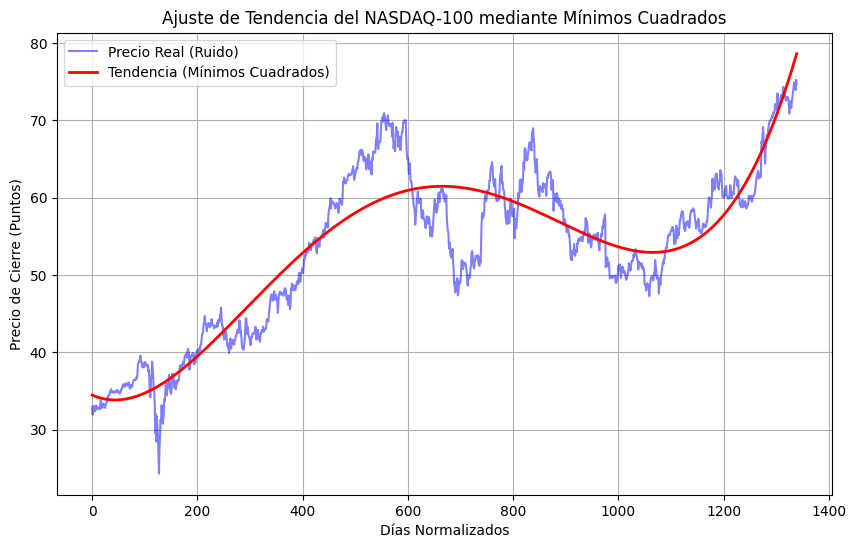

In [5]:
# ETAPA 3: REGRESIÓN POLINOMIAL (MÍNIMOS CUADRADOS)

# 1. Preparación de variables
# Asumiendo que 'df' es tu DataFrame limpio de la Etapa 1
t = df_analisis['t'].values # Variable independiente: días normalizados (0, 1, 2...)
y = df_analisis['Close'].values # Variable dependiente: precio de cierre

# 2. Definición del modelo
grado = 4
num_coeficientes = grado + 1

# 3. Construcción de la matriz de Vandermonde (A)
# Debes crear una matriz de ceros de tamaño (len(t), num_coeficientes)
# y llenarla iterativamente de forma que la columna j sea t^j
A = np.zeros((len(t), num_coeficientes))
# [TU CÓDIGO AQUÍ PARA LLENAR LA MATRIZ]
for i in range (0, num_coeficientes):
    for j in range(len(t)): # Correcion: usar range(len(t)) en lugar de len(t)
        A[j][i] = t[j] ** i

# 4. Construcción del sistema de ecuaciones normales
# Calcular A transpuesta
A_T = np.transpose(A)

# Calcular (A^T * A) y (A^T * y) usando np.dot o el operador @
matriz_normal = np.dot(A_T, A)
vector_normal = np.dot(A_T, y)

# 5. Resolución del sistema cuadrado
# Puedes usar np.linalg.solve para resolver el sistema resultante
coeficientes = np.linalg.solve(matriz_normal, vector_normal)

# 6. Evaluación del modelo polinomial
# P(t) = a0 + a1*t + a2*t^2 + ...
y_pred = np.dot(A, coeficientes)

# 7. Visualización inicial
plt.figure(figsize=(10, 6)) # Define un tamaño adecuado para el documento

# Se usa alpha=0.5 para dar transparencia al ruido diario y permitir que resalte la tendencia
plt.plot(t, y, color='blue', alpha=0.5, label='Precio Real (Ruido)')

# Se usa linewidth para engrosar la línea calculada
plt.plot(t, y_pred, color='red', linewidth=2, label='Tendencia (Mínimos Cuadrados)')

plt.title('Ajuste de Tendencia del NASDAQ-100 mediante Mínimos Cuadrados')
plt.xlabel('Días Normalizados')
plt.ylabel('Precio de Cierre (Puntos)')
plt.legend()
plt.grid(True)
plt.show()

#TODO: eliminar comentarios, revisar referencias